*Importing* the Dependencies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt

from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection & Analysis

In [ ]:
# loading the data from csv file to a Pandas DataFrame
parkinsons_data = pd.read_csv('/content/parkinsons_dataset.csv')

In [ ]:
# printing the first 5 rows of the dataframe
parkinsons_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
# print last 5 rows of the dataset
parkinsons_data.tail()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,phon_R01_S50_6,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,...,0.03078,0.04398,21.209,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569


In [ ]:
# number of rows and columns in the dataframe
parkinsons_data.shape

(195, 24)

In [ ]:
# getting more information about the dataset
parkinsons_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
# checking for missing values in each column
parkinsons_data.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [ ]:
# getting some statistical measures about the data
parkinsons_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [ ]:
# distribution of target Variable
parkinsons_data['status'].value_counts()

,count
status,
1,147
0,48


1  --> Parkinson's Positive

0 --> Healthy


In [ ]:
# Grouping the data based on the 'status' variable and calculating the mean of numeric columns
numeric_columns = parkinsons_data.select_dtypes(include=['number'])
grouped_mean = numeric_columns.groupby('status').mean()

# Displaying the grouped mean
print(grouped_mean)

        MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
status                                                            
0        181.937771    223.636750    145.207292        0.003866   
1        145.180762    188.441463    106.893558        0.006989   

        MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
status                                                                   
0               0.000023  0.001925  0.002056    0.005776      0.017615   
1               0.000051  0.003757  0.003900    0.011273      0.033658   

        MDVP:Shimmer(dB)  ...  MDVP:APQ  Shimmer:DDA       NHR        HNR  \
status                    ...                                               
0               0.162958  ...  0.013305     0.028511  0.011483  24.678750   
1               0.321204  ...  0.027600     0.053027  0.029211  20.974048   

            RPDE       DFA   spread1   spread2        D2       PPE  
status                                                  

Data Pre-Processing

Separating the features & Target

In [ ]:
X = parkinsons_data.drop(columns=['name','status'], axis=1)
Y = parkinsons_data['status']

In [ ]:
print(X)

     MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0        119.992       157.302        74.997         0.00784   
1        122.400       148.650       113.819         0.00968   
2        116.682       131.111       111.555         0.01050   
3        116.676       137.871       111.366         0.00997   
4        116.014       141.781       110.655         0.01284   
..           ...           ...           ...             ...   
190      174.188       230.978        94.261         0.00459   
191      209.516       253.017        89.488         0.00564   
192      174.688       240.005        74.287         0.01360   
193      198.764       396.961        74.904         0.00740   
194      214.289       260.277        77.973         0.00567   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0             0.00007   0.00370   0.00554     0.01109       0.04374   
1             0.00008   0.00465   0.00696     0.01394       0.06134   
2             0.00

In [ ]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64


Splitting the data to training data & Test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(195, 22) (156, 22) (39, 22)


Model Training

                           Support Vector Machine Model (SVM)

In [ ]:
from sklearn import svm
model = svm.SVC(kernel='linear', probability=True)

In [ ]:
# training the SVM model with training data
model.fit(X_train, Y_train)

SVC(kernel='linear', probability=True)

Model Evaluation

Accuracy Score

In [ ]:
# accuracy score on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 87.18%


In [ ]:
# accuracy score on testing data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,Y_test)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the testing data: {formatted_accuracy}')

Accuracy score of the testing data: 87.18%


CLASSIFICATION REPORT

In [ ]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       0.88      0.97      0.92        31

    accuracy                           0.87        39
   macro avg       0.84      0.73      0.77        39
weighted avg       0.87      0.87      0.86        39



Building a Predictive System

In [ ]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[0]
The Person does not have Parkinsons Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

Training Data Metrics:
Accuracy: 87.18%
Precision: 86.87%
Recall: 87.18%
F1 Score: 86.53%

Test Data Metrics:
Accuracy: 87.18%
Precision: 86.55%
Recall: 87.18%
F1 Score: 86.00%


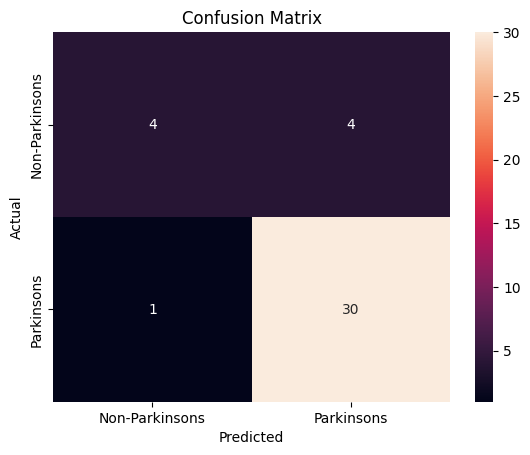

In [ ]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Parkinsons', 'Parkinsons'],
            yticklabels=['Non-Parkinsons', 'Parkinsons'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

                       Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model2 = GradientBoostingClassifier(loss='exponential', learning_rate=0.1, n_estimators=200, max_features=None)

In [ ]:
# training the GB model with training data
model2.fit(X_train, Y_train)

GradientBoostingClassifier(loss='exponential', n_estimators=200)

Model Evaluation

Accuracy Score

In [ ]:
# accuracy score on training data
X_train_prediction = model2.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 100.00%


In [ ]:
# accuracy score on testing data
X_test_prediction = model2.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the test data: {formatted_accuracy}')

Accuracy score of the test data: 84.62%


Training Data Metrics:
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%

Test Data Metrics:
Accuracy: 84.62%
Precision: 84.62%
Recall: 84.62%
F1 Score: 84.62%


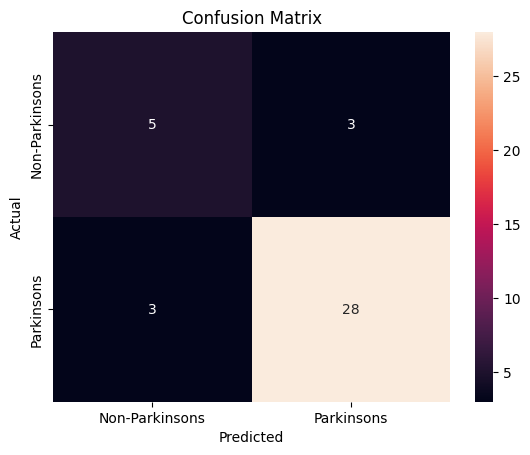

In [ ]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Parkinsons', 'Parkinsons'],
            yticklabels=['Non-Parkinsons', 'Parkinsons'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CONFUSION MATRIX

CLASSIFICATION REPORT

In [ ]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.90      0.90      0.90        31

    accuracy                           0.85        39
   macro avg       0.76      0.76      0.76        39
weighted avg       0.85      0.85      0.85        39



Building a Predictive System

In [ ]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model2.predict(input_data_reshaped)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[0]
The Person does not have Parkinsons Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


                 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model4 = LogisticRegression()

In [ ]:
# training the LogisticRegression model with Training data
model4.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

Accuracy Score

In [ ]:
# accuracy on training data
X_train_prediction = model4.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 87.82%


In [ ]:
# accuracy on test data
X_test_prediction = model4.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the test data: {formatted_accuracy}')

Accuracy score of the test data: 87.18%


Training Data Metrics:
Accuracy: 87.82%
Precision: 87.48%
Recall: 87.82%
F1 Score: 87.41%

Test Data Metrics:
Accuracy: 87.18%
Precision: 86.55%
Recall: 87.18%
F1 Score: 86.00%


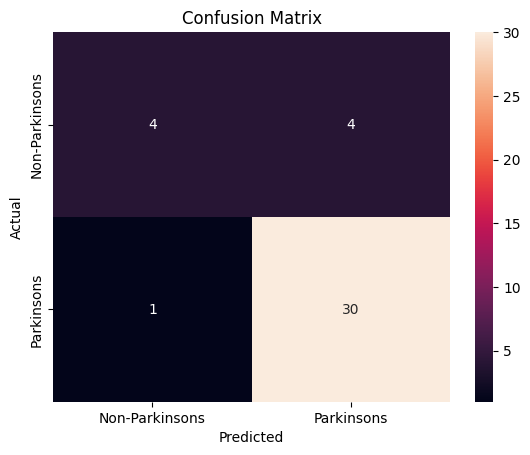

In [ ]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Parkinsons', 'Parkinsons'],
            yticklabels=['Non-Parkinsons', 'Parkinsons'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT

In [ ]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       0.88      0.97      0.92        31

    accuracy                           0.87        39
   macro avg       0.84      0.73      0.77        39
weighted avg       0.87      0.87      0.86        39



Building a Predictive System

In [ ]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model4.predict(input_data_reshaped)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[0]
The Person does not have Parkinsons Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Performance Metrics Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
                SVM     87.18      86.55   87.18     86.00
  Gradient Boosting     84.62      84.62   84.62     84.62
Logistic Regression     87.18      86.55   87.18     86.00


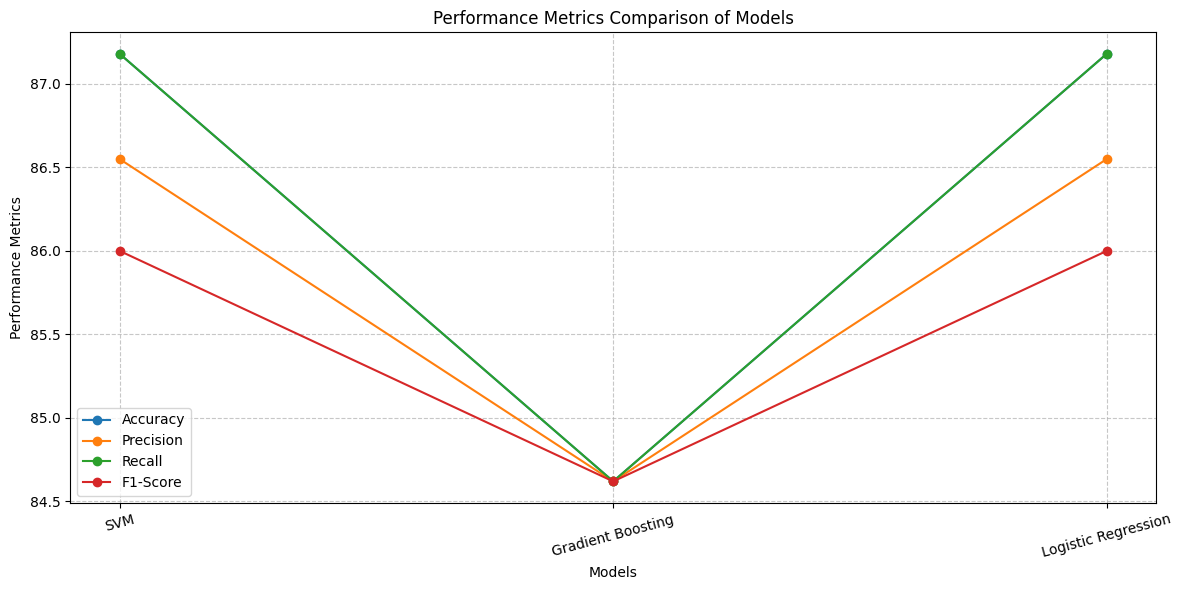

In [ ]:
data = {
    'Model': ['SVM', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [87.18, 84.62, 87.18],
    'Precision': [86.55, 84.62, 86.55],
    'Recall': [87.18,  84.62, 87.18],
    'F1-Score': [86.00, 84.62, 86.00]
}

metrics_df = pd.DataFrame(data)

# Display the table
print("Performance Metrics Comparison:")
print(metrics_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    plt.plot(metrics_df['Model'], metrics_df[metric], marker='o', linestyle='-', label=metric)

plt.xlabel('Models')
plt.ylabel('Performance Metrics')
plt.title('Performance Metrics Comparison of Models')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b3ddc9d86bb084ea8c44f5d8097ff4cfe8bc76c192365affc5c3942f57a4029b
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import shap
import lime
import lime.lime_tabular

In [ ]:
# SHAP implementation
explainer_shap = shap.Explainer(model.predict, X_test)
shap_values = explainer_shap(X_test)

PermutationExplainer explainer: 40it [00:17,  2.29it/s]


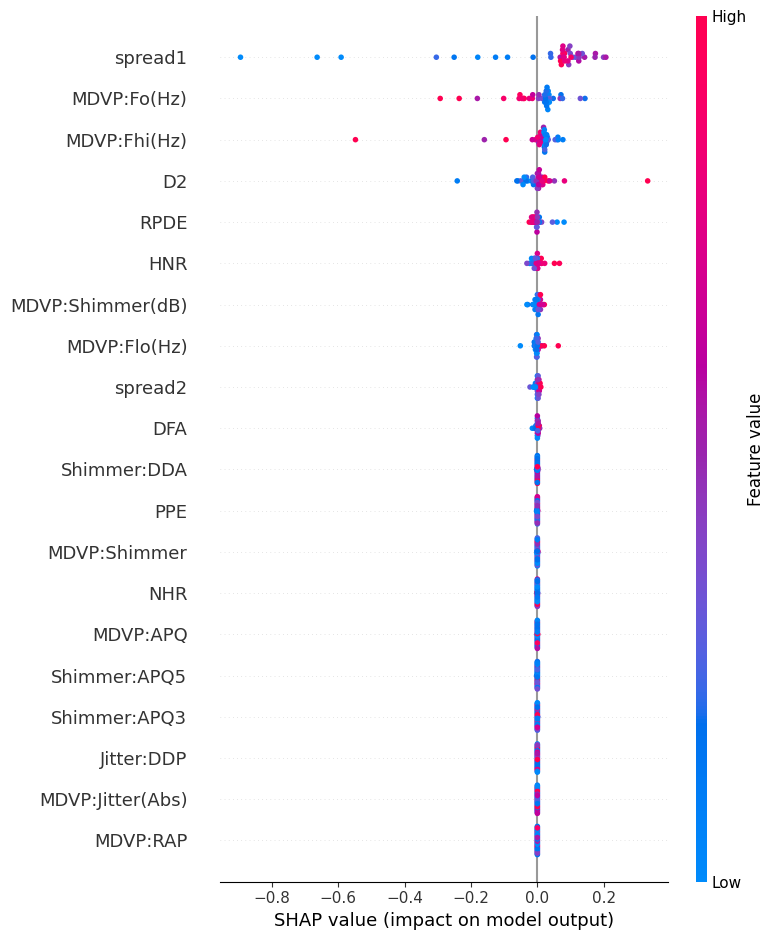

In [ ]:
# Summary plot to visualize feature importance using SHAP
shap.summary_plot(shap_values, X_test)

In [ ]:
# SHAP Fidelity (Agreement with Model Predictions)
shap_fidelity = np.mean(np.abs(shap_values.values.sum(axis=1) - model.decision_function(X_test)))

# SHAP Interpretability (Avg. Number of Features Contributing)
shap_interpretability = np.mean(np.count_nonzero(shap_values.values, axis=1))

# SHAP Unambiguity (Standard Deviation of Feature Importance)
shap_unambiguity = np.mean(np.std(shap_values.values, axis=0))


In [ ]:
print("SHAP XAI Performance Metrics")
print(f"SHAP Fidelity: {shap_fidelity:.4f}")
print(f"SHAP Interpretability (Avg Features Used): {shap_interpretability:.2f}")
print(f"SHAP Unambiguity: {shap_unambiguity:.4f}")

SHAP XAI Performance Metrics
SHAP Fidelity: 1.5101
SHAP Interpretability (Avg Features Used): 9.97
SHAP Unambiguity: 0.0256


In [ ]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['No Parkinsons', 'Parkinsons'], mode='classification')

In [ ]:
sample_index = 0
exp = explainer_lime.explain_instance(X_test.iloc[sample_index].values, model.predict_proba, num_features=len(X_test.columns))

exp.show_in_notebook()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
lime_exp = exp
instance = X_test.iloc[0].values
# LIME Fidelity (Agreement with Model Predictions)
lime_fidelity = np.mean([abs(lime_exp.local_pred[0] - model.predict_proba([instance])[0][0])])

# LIME Interpretability (Number of Features Used)
lime_interpretability = len(lime_exp.as_list())

# LIME Unambiguity (Standard Deviation of Feature Importance)
lime_unambiguity = np.std([abs(weight) for _, weight in lime_exp.as_list()])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
print("LIME XAI Performance Metrics")
print(f"LIME Fidelity: {lime_fidelity:.4f}")
print(f"LIME Interpretability: {lime_interpretability}")
print(f"LIME Unambiguity: {lime_unambiguity:.4f}")

LIME XAI Performance Metrics
LIME Fidelity: 0.9068
LIME Interpretability: 22
LIME Unambiguity: 0.0405


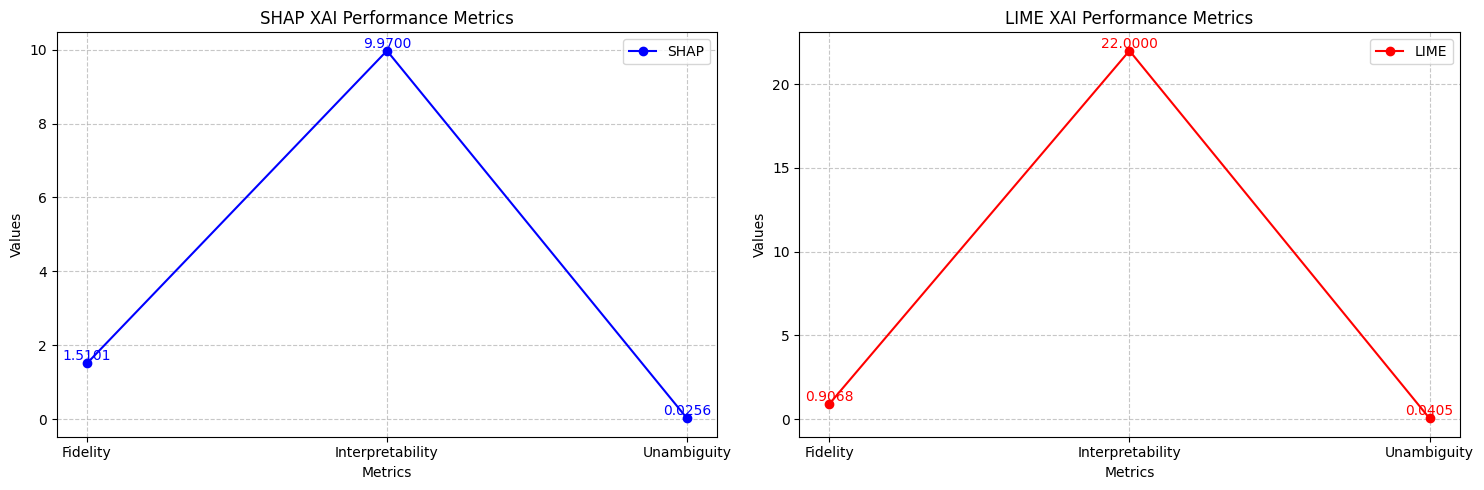

In [ ]:
# SHAP and LIME Performance Metrics
data_shap = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [1.5101, 9.97, 0.0256]
}

data_lime = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [0.9068, 22.00, 0.0405]
}

shap_df = pd.DataFrame(data_shap)
lime_df = pd.DataFrame(data_lime)

# Plot SHAP and LIME Metrics Side by Side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# SHAP Plot
axes[0].plot(shap_df['Metric'], shap_df['Value'], marker='o', linestyle='-', color='blue', label='SHAP')
for i, txt in enumerate(shap_df['Value']):
    axes[0].text(i, shap_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='blue')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Values')
axes[0].set_title('SHAP XAI Performance Metrics')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# LIME Plot
axes[1].plot(lime_df['Metric'], lime_df['Value'], marker='o', linestyle='-', color='red', label='LIME')
for i, txt in enumerate(lime_df['Value']):
    axes[1].text(i, lime_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='red')
axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Values')
axes[1].set_title('LIME XAI Performance Metrics')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

Saving the trained model

In [ ]:
import pickle

In [ ]:
filename = 'parkinsons_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [ ]:
# loading the saved model
loaded_model = pickle.load(open('parkinsons_model.sav', 'rb'))

In [ ]:
for column in X.columns:
  print(column)

MDVP:Fo(Hz)
MDVP:Fhi(Hz)
MDVP:Flo(Hz)
MDVP:Jitter(%)
MDVP:Jitter(Abs)
MDVP:RAP
MDVP:PPQ
Jitter:DDP
MDVP:Shimmer
MDVP:Shimmer(dB)
Shimmer:APQ3
Shimmer:APQ5
MDVP:APQ
Shimmer:DDA
NHR
HNR
RPDE
DFA
spread1
spread2
D2
PPE
